### 지도학습 절차

- 지도학습 : 목표변수(Y)와 설명변수(X)의 관계를 학습해서, 새로운 X가 들어올 때, Y를 예측 / 분류

- 지도학습의 절차 6단계:
  1. 데이터 핸들링 (데이터 불러오기 / 파생변수 생성 / 층별화) : 데이터 구조적인 관점에서 학습을 수행할 수 있는 데이터셋을 구성하는 과정

  2. 학습에 사용될 목표변수(Y)와 설명변수(X)를 설정
    - 유의사항 : 사용되는 X는 새로 들어올 데이터에 대한 값으로 지정 ex. 신규고객 이탈 예측을 할 때 구매횟수와 방문횟수를 넣으면 안 됨.

  3. 학습 데이터(Train Set)와 검증 데이터(Test Set)분할
    - 검증 데이터(Test Set)는 학습에 참여하지 않는다! (교차검증에서 Validation Set과는 다른 개념)

  4. 학습을 수행 (Modeling)
    - 특성공학 (결측값 처리 / Encoding / Scaling ...) -> Pipe Line을 이용해서
    - 학습 (알고리즘)

  5. 학습된 모델 평가
    - 학습 능력 평가
    - 일반화 능력 평가


In [345]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt     
plt.rc('font', family='Malgun Gothic') 
import koreanize_matplotlib       

from IPython.display import display
import seaborn as sns          

- 사용한 데이터 (https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [346]:
# 데이터 불러오기
df1 = pd.read_csv('diabetes.csv')
print(df1.shape)
print(df1.info())
print(df1.head())
print(df1.tail())
print(df1.columns)

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2         

In [347]:
# 환자의 건강 관련 정보를 입력했을 때, 당뇨병에 걸릴지 말지에 대한 판별 모델 생성
# 1) 데이터 핸들링
df1['Outcome'].unique()

array([1, 0])

## **결측치는 없지만 0이 나올 수 있는 변수와 아닌 변수를 구분해서 EDA 할 것**

< 당뇨병과 변수들의 상관관계 >

1. Pregnancies : 횟수 많을수록 당뇨병 확률 높음 (연관 변수 : 혈당) 
2. Glucose : 혈당 높을수록 당뇨병 확률 높음 
3. BloodPressure : 고혈압일수록 당뇨병 확률 높음 (연관 변수 : BMI) 
4. SkinThickness : 두꺼울수록 당뇨병 확률 높음 (연관 변수 : BMI)  
5. Insulin 
- 제1형 당뇨병 : 인슐린 분비가 안 됨 => 인슐린 수치 낮을수록 당뇨병 확률 높음
- 제2형 당뇨병 : 인슐린 작용이 안 됨 => 혈당 안 떨어짐 => 인슐린 수치 높을수록 당뇨병 확률 높음
6. BMI : 23이상이면 당뇨병 확률 높음

## **Pregrance**
 - 임신횟수
 - 0 가능

In [348]:
df1["Pregnancies"].value_counts()

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64

<Axes: >

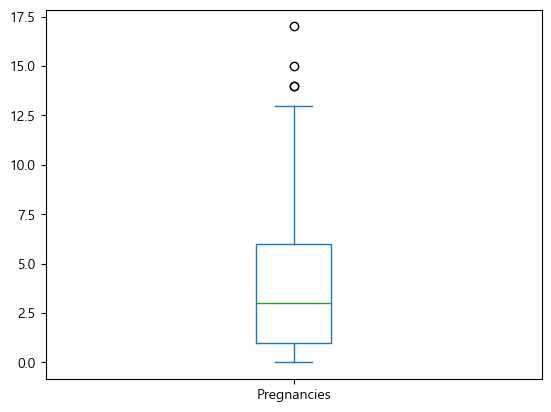

In [349]:
df1['Pregnancies'].plot.box()

In [350]:
df1.groupby("Outcome")["Pregnancies"].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,3.298000,3.017185,0.0,1.00,2.0,5.0,13.0
1,268.0,4.865672,3.741239,0.0,1.75,4.0,8.0,17.0


### **변수 인사이트 정리**
    - 임신 횟수 1이 가장 많고 0~17까지 존재
    - 13 이상이 이상치이지만 가능하기 때문에 그대로 유지
    - 정상과 당뇨병의 임신 횟수 평균이 각각 3,5로 비슷함

## **glucose**
- 혈장 포도당 농도
- 사람 혈당이 0일 수는 없다. => NA로 인지
- 당뇨는 혈당이 지속적으로 높은 증상

In [351]:
df1["Glucose"].value_counts()

Glucose
99     17
100    17
111    14
129    14
125    14
       ..
191     1
177     1
44      1
62      1
190     1
Name: count, Length: 136, dtype: int64

In [352]:
df1[df1["Glucose"] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [353]:
df1 = df1[df1["Glucose"] != 0]

In [354]:
df1[df1["Glucose"] == 0] 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


<Axes: xlabel='Glucose', ylabel='Count'>

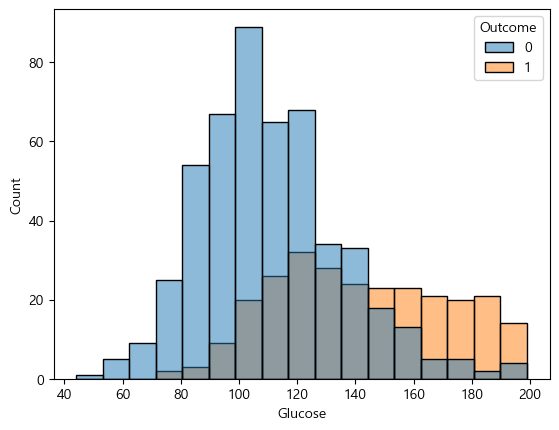

In [355]:
sns.histplot(data=df1, x="Glucose", hue="Outcome")

### **변수 인사이트 정리**
    - Glucose는 0이 될 수 없어 0인 5개의 값은 삭제 (적은 양이라 대체 안 하고 삭제 => 과적합 방지)
    - 1 (당뇨병)이 혈당이 높을수록 많아지는 것을 확인
    - 0 (정상)은 혈당이 평균 80~120에 분포

## **bloodpressure**
- 혈압
- 혈압도 0일 수는 없다 => NA로 인지

In [356]:
df1["BloodPressure"].value_counts().head(10) # BloodPressure = 0인 행 35개

BloodPressure
70    57
74    51
78    45
72    44
64    43
68    43
80    39
76    39
60    37
0     35
Name: count, dtype: int64

In [357]:
df1[df1["BloodPressure"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115,0,0,0,35.3,0.134,29,0
15,7,100,0,0,0,30.0,0.484,32,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
78,0,131,0,0,0,43.2,0.270,26,1
81,2,74,0,0,0,0.0,0.102,22,0
172,2,87,0,23,0,28.9,0.773,25,0
193,11,135,0,0,0,52.3,0.578,40,1
222,7,119,0,0,0,25.2,0.209,37,0
261,3,141,0,0,0,30.0,0.761,27,1


In [358]:
df1 = df1[df1["BloodPressure"] != 0]

<Axes: xlabel='BloodPressure', ylabel='Count'>

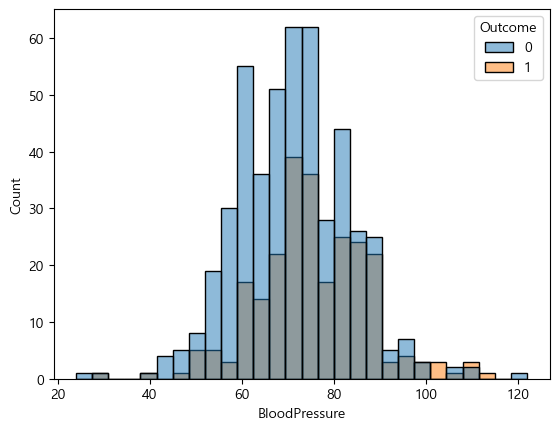

In [359]:
sns.histplot(data=df1, x="BloodPressure", hue="Outcome")

In [360]:
print(df1.groupby("Outcome")["BloodPressure"].mean())

Outcome
0    70.924686
1    75.332000
Name: BloodPressure, dtype: float64


In [361]:
df1['BloodPressure'].describe()

count    728.000000
mean      72.438187
std       12.386109
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

### **변수 인사이트 정리**
    - BloodPressure는 0이 될 수 없어서 35개의 행 삭제
    - 정상인과 당뇨병 환자의 평균 혈압은 각 71, 75로 당뇨병 환자의 혈압이 더 높았음

    - 원래 혈압이 높을수록 당뇨병 확률이 높음 => 다른 변수와의 작용이 있을 것으로 예상

## **SkinThickness**
- 삼두근 피부 두께
- 체지방이란 관련이 있다.
- 0일 수 없다 => NA로 인지

In [362]:
df1["SkinThickness"].value_counts().head(10) # SkinThickness=0인 행 194개 => 지울 수 없음

SkinThickness
0     194
32     30
30     26
27     23
23     21
28     20
18     20
33     20
31     19
39     18
Name: count, dtype: int64

In [363]:
df1["SkinThickness"].describe()

count    728.000000
mean      21.388736
std       15.729793
min        0.000000
25%        0.000000
50%       24.000000
75%       33.000000
max       99.000000
Name: SkinThickness, dtype: float64

In [364]:
df1["SkinThickness"] = df1["SkinThickness"].replace([0, 99], np.nan)

In [365]:
df1.groupby("Outcome")["SkinThickness"].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,357.0,27.266106,10.057101,7.0,19.00,27.0,33.0,60.0
1,176.0,32.602273,9.144603,7.0,26.75,32.0,39.0,63.0


### **변수 인사이트 정리**
    - 0인 행이 194개 존재, 99인 행도 존재 (99도 불가능)
    - XGBoost는 결측치 스스로 처리하기 때문에 지우지 않고 np.nan로 대체
    - 정상인의 심두근 두께가 당뇨병 환자의 심두근 두께보다 얇음
    
    + 다른 분류 방법이었다면 중앙값으로 대체 : 
    df1["SkinThickness"] = df1["SkinThickness"].replace([0, 99], np.nan))
    st_median = df1["SkinThickness"].median()
    df1["SkinThickness"] = df1["SkinThickness"].fillna(st_median)
    

## **Insulin**
- 인슐린 분비량
- 당뇨병 유형은 인슐린이 선천적으로 나오지 않는 사람(1형)과 인슐린이 나오지만 인식을 못하는 사람(2형) 당뇨병 두가지가 있다.  

In [366]:
df1["Insulin"].value_counts().head() # Insulin=0인 행 335개 => 지울 수 없음

Insulin
0      335
105     11
130      9
140      9
120      8
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

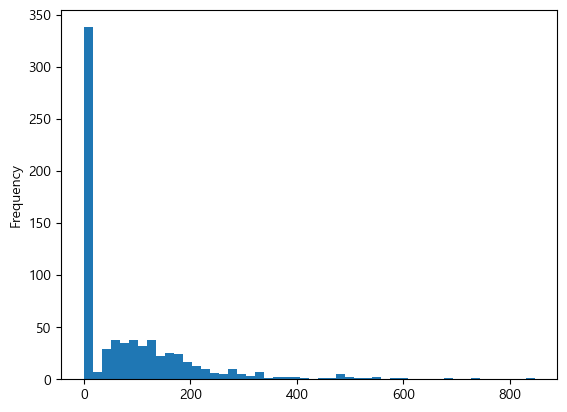

In [367]:
df1["Insulin"].plot.hist(bins=50)

In [368]:
df1['Insulin'] = df1['Insulin'].replace(0, np.nan)

In [369]:
# 혈당에 범주에 따라서 인슐린 결측치 채우기
# ~140 : 저혈당 / 140~199 : 당뇨병 전단계 / 200~ : 당뇨병
bins = [0, 140, 200, np.inf]
df1["Glucose_Category"] = pd.cut(df1["Glucose"], bins=bins, right=False)
df1["Insulin"] = df1.groupby("Glucose_Category")["Insulin"].transform(lambda x: x.fillna(x.median()))

C:\Users\82105\AppData\Local\Temp\ipykernel_25980\2998391298.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1["Insulin"] = df1.groupby("Glucose_Category")["Insulin"].transform(lambda x: x.fillna(x.median()))


<Axes: ylabel='Frequency'>

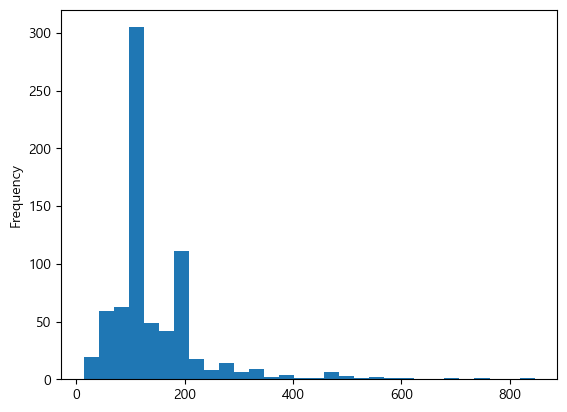

In [370]:
df1["Insulin"].plot.hist(bins=30)

In [371]:
df1["Insulin"].describe()

count    728.000000
mean     142.494505
std       92.127491
min       14.000000
25%      105.000000
50%      105.000000
75%      190.000000
max      846.000000
Name: Insulin, dtype: float64

In [372]:
df1 = df1.drop(columns=["Glucose_Category"])

In [373]:
df1.groupby("Outcome")["Insulin"].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,478.0,123.979079,78.748755,15.0,94.0,105.0,129.5,744.0
1,250.0,177.896000,104.807287,14.0,105.0,166.0,194.0,846.0


<Axes: xlabel='Outcome', ylabel='Insulin'>

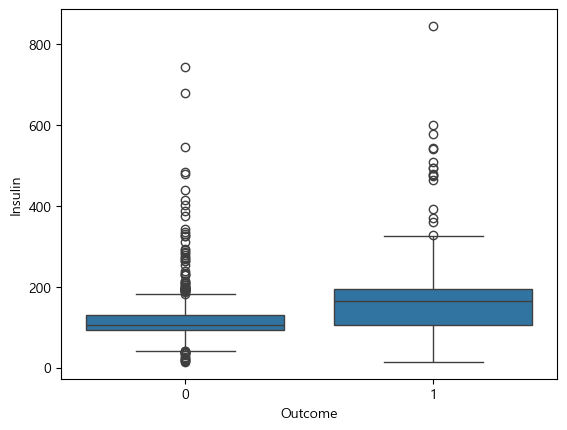

In [374]:
sns.boxplot(x="Outcome", y="Insulin", data=df1)

In [375]:
df1.loc[df1["Outcome"] == 1,"Insulin"].describe()

count    250.000000
mean     177.896000
std      104.807287
min       14.000000
25%      105.000000
50%      166.000000
75%      194.000000
max      846.000000
Name: Insulin, dtype: float64

### **변수 인사이트 정리**
    - Insulin이 0인 값이 335개로 삭제 불가능 
    (인슐린이 0인 1형 당뇨병은 소아나 30세 미만에게 주로 발병, 데이터 타겟인 21세이상 여성과는 부합하지 않을 확률이 높아 0일 가능성 배제함)
    => 인슐린이 혈당과 관련이 있으므로 혈당 범주에 따른 중앙값으로 그 범주 내에 있는 인슐린 결측치를 대체
    - 정상인 인슐린 수치의 평균, 중앙값 모두 당뇨병 환자보다 낮음

## **BMI**
- 0이 나올 수 없는 값 => NA로 인지

In [376]:
df1["BMI"].describe()

count    728.000000
mean      32.288736
std        7.277660
min        0.000000
25%       27.400000
50%       32.300000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

In [377]:
df1[ df1["BMI"] == 0 ] # BMI = 0인 행 4개

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125,96,NaN,105.0,0.0,0.232,54,1
145,0,102,75,23.0,105.0,0.0,0.572,21,0
371,0,118,64,23.0,89.0,0.0,1.731,21,0
684,5,136,82,NaN,105.0,0.0,0.640,69,0


In [378]:
df1 = df1[df1["BMI"] != 0]

In [379]:
df1["BMI"].describe()

count    724.000000
mean      32.467127
std        6.888941
min       18.200000
25%       27.500000
50%       32.400000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

In [380]:
df1.groupby("Outcome")["BMI"].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,475.0,30.974947,6.571093,18.2,25.9,30.4,35.4,57.3
1,249.0,35.313655,6.589824,22.9,30.9,34.3,38.5,67.1


<Axes: xlabel='Outcome', ylabel='BMI'>

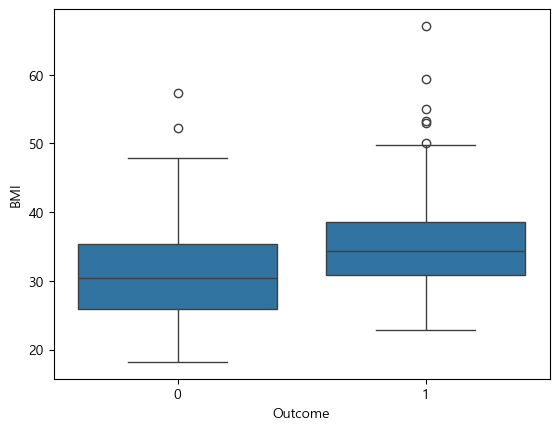

In [381]:
sns.boxplot(x='Outcome', y='BMI',data=df1)

### **변수 인사이트 정리**
    - BMI = 0인 행 4개 제거
    - 당뇨병 환자의 BMI 수치 중앙값과 평균 모두 정상인보다 높음

## **파생변수 생성 및 추가 전처리**

## DiabetesPedigreeFunction / Age 
### 1. DiabetesPedigreeFunction : 당뇨병 혈통 기능 (당뇨병 발병 위험도를 나타냄)

In [382]:
df1["DiabetesPedigreeFunction"].describe()

count    724.000000
mean       0.474765
std        0.332315
min        0.078000
25%        0.245000
50%        0.379000
75%        0.627500
max        2.420000
Name: DiabetesPedigreeFunction, dtype: float64

<Axes: >

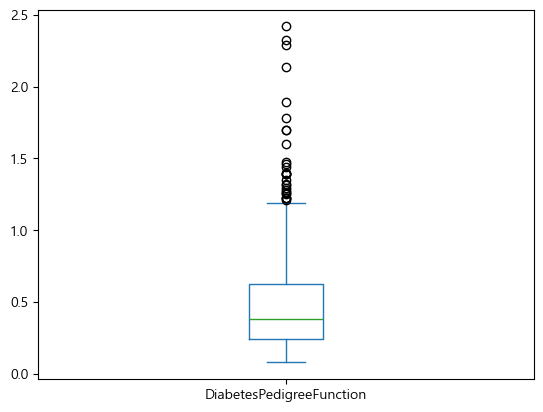

In [383]:
df1["DiabetesPedigreeFunction"].plot.box()

In [384]:
df1.groupby("Outcome")["DiabetesPedigreeFunction"].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,475.0,0.430297,0.295905,0.078,0.232,0.338,0.5605,2.329
1,249.0,0.559594,0.378925,0.088,0.268,0.452,0.7320,2.420


<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Count'>

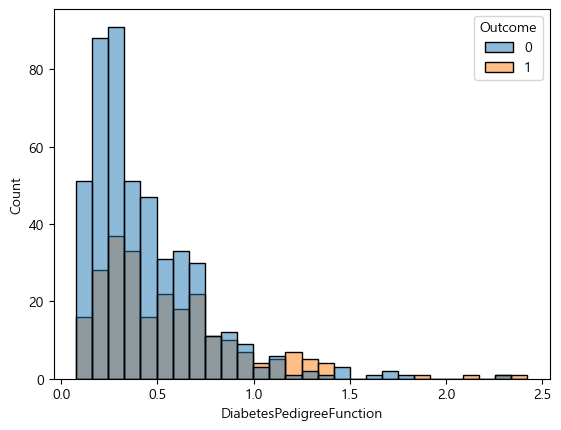

In [385]:
sns.histplot(data=df1, x="DiabetesPedigreeFunction", hue="Outcome")

### DiabetesPedigreeFunction가 정상인보다 당뇨병 환자에게서 더 높게 나타남
### 주로 0~1.0 사이에 분포

### 2. Age

In [386]:
df1["Age"].describe()

count    724.000000
mean      33.350829
std       11.765393
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64

In [387]:
df1.groupby("Outcome")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,475.0,31.258947,11.561535,21.0,23.0,27.0,37.0,81.0
1,249.0,37.341365,11.122120,21.0,28.0,36.0,45.0,70.0


<Axes: xlabel='Outcome', ylabel='Age'>

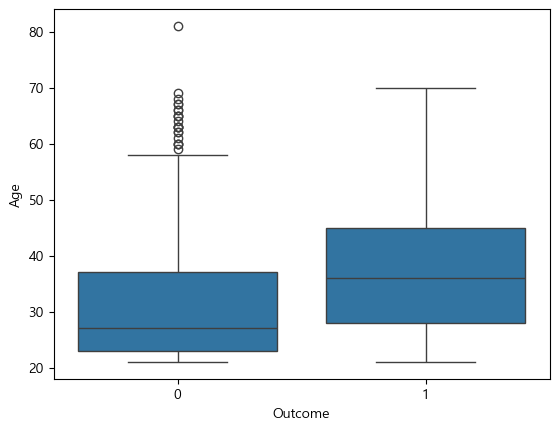

In [388]:
sns.boxplot(x='Outcome', y='Age',data=df1)

### 나이가 많을수록 당뇨병 환자 많음
### 정상인의 범주에서 나이가 적은 사람들쪽으로 몰려있음

# 파생변수 생성

## 1. BMI_Group : BMI 구간화 

In [389]:
# ~18.5:Underweight / 18.5~23:Normal / 23~35:Overweight / 35~:Obese으로 구간화
bins = [0.1, 18.5, 23, 35, np.inf]
group_names = ["Underweight", "Normal", "Overweight", "Obese"]

In [390]:
# BMI_Group 생성
df1["BMI_Group"] = pd.cut( df1["BMI"], bins=bins, labels=group_names, right=False )

In [391]:
print(df1["BMI_Group"].value_counts().sort_index())

BMI_Group
Underweight      4
Normal          43
Overweight     440
Obese          237
Name: count, dtype: int64


In [392]:
pd.crosstab(df1['BMI_Group'], df1['Outcome'], normalize='columns')

Outcome,0,1
BMI_Group,,
Underweight,0.008421,0.000000
Normal,0.088421,0.004016
Overweight,0.633684,0.558233
Obese,0.269474,0.437751


In [393]:
pd.crosstab(df1['BMI_Group'], df1['Outcome'], normalize='index')

Outcome,0,1
BMI_Group,,
Underweight,1.000000,0.000000
Normal,0.976744,0.023256
Overweight,0.684091,0.315909
Obese,0.540084,0.459916


<Axes: xlabel='BMI_Group', ylabel='count'>

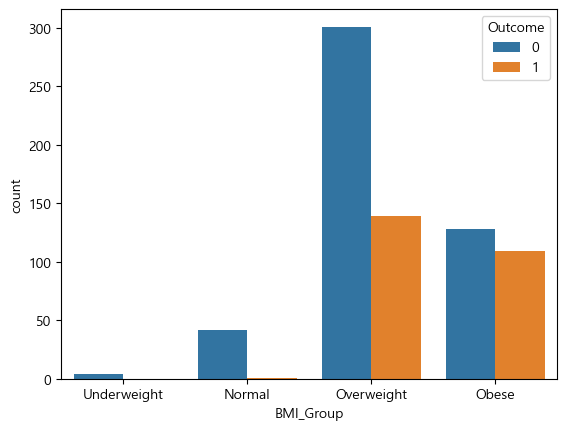

In [394]:
sns.countplot(x="BMI_Group", hue="Outcome", data=df1)

### 전체에서 구간별 비율을 분석하면 고도비만 전 과체중일 때 당뇨병 비율이 가장 높음
### 또한 고도비만 구간에서 당뇨병 환자와 정상인의 비율이 비슷함

## 2. Age_Group : Age 구간화

In [395]:
# 21~81까지의 나이를 4개의 구간으로 나눔
df1["Age_Group"] = pd.cut( df1["Age"], bins=4, labels=("Young", "Middle", "Senior", "Elderly"), right=False )

In [396]:
df1["Age_Group"].value_counts()

Age_Group
Young      467
Middle     179
Senior      67
Elderly     11
Name: count, dtype: int64

In [397]:
pd.crosstab(df1['Age_Group'], df1['Outcome'], normalize='index')

Outcome,0,1
Age_Group,,
Young,0.743041,0.256959
Middle,0.486034,0.513966
Senior,0.507463,0.492537
Elderly,0.636364,0.363636


<Axes: xlabel='Age_Group', ylabel='count'>

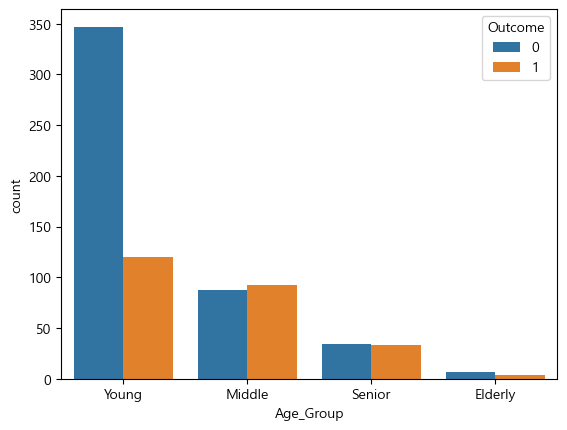

In [398]:
sns.countplot(x="Age_Group", hue="Outcome", data=df1)

### 21~36세:Young / 36~51세:Middle / 51~66세:Senior / 66~81세:Elderly
### 나이가 어릴수록 당뇨병의 비율이 적음

# **모델링하기**

In [399]:
df1.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Group,Age_Group
0,6,148,72,35.0,194.0,33.6,0.627,50,1,Overweight,Middle
1,1,85,66,29.0,105.0,26.6,0.351,31,0,Overweight,Young
2,8,183,64,NaN,194.0,23.3,0.672,32,1,Overweight,Young
3,1,89,66,23.0,94.0,28.1,0.167,21,0,Overweight,Young
4,0,137,40,35.0,168.0,43.1,2.288,33,1,Obese,Young
5,5,116,74,NaN,105.0,25.6,0.201,30,0,Overweight,Young
6,3,78,50,32.0,88.0,31.0,0.248,26,1,Overweight,Young
8,2,197,70,45.0,543.0,30.5,0.158,53,1,Overweight,Senior
10,4,110,92,NaN,105.0,37.6,0.191,30,0,Obese,Young
11,10,168,74,NaN,194.0,38.0,0.537,34,1,Obese,Young


In [400]:
df1.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               193
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
BMI_Group                     0
Age_Group                     0
dtype: int64

In [401]:
df2=df1.copy()

### df2는 XGBoost를 위해 결측치 보존한 데이터

In [402]:
df1["SkinThickness"] = df1["SkinThickness"].replace([0, 99], np.nan)
st_median = df1["SkinThickness"].median()
df1["SkinThickness"] = df1["SkinThickness"].fillna(st_median)

In [403]:
df1.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
BMI_Group                   0
Age_Group                   0
dtype: int64

In [404]:
# 2) 목표변수 / 설명변수 설정
# 파생 변수는 추가하고, 필요 없는 변수는 빼기

X = df1[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction','BMI_Group','Age_Group']]
Y = df1['Outcome'] # Y값에는 결측치가 존재해서는 안됨

In [405]:
# 3) 학습데이터와 검증데이터를 분할
# pip install scikit-learn
from sklearn.model_selection import train_test_split

In [406]:
train_test_split(X,Y) # X 데이터의 학습, 검증 데이터 & Y 데이터의 학습, 검증데이터 4개로 분리됨

[     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
 302            5       77             82           41.0     42.0   
 496            5      110             68           29.0    105.0   
 134            2       96             68           13.0     49.0   
 549            4      189            110           31.0    194.0   
 168            4      110             66           29.0    105.0   
 ..           ...      ...            ...            ...      ...   
 242            3      139             54           29.0    105.0   
 695            7      142             90           24.0    480.0   
 709            2       93             64           32.0    160.0   
 413            1      143             74           22.0     61.0   
 192            7      159             66           29.0    194.0   
 
      DiabetesPedigreeFunction   BMI_Group Age_Group  
 302                     0.156       Obese     Young  
 496                     0.292  Overweight     Young  
 134 

In [407]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=1234)
# train_test_split()에 별도의 옵션을 지정하지 않으면 75:25로 학습:검증 분할됨
# random_state을 지정해야 같은 결과가 나옴

In [408]:
X.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
DiabetesPedigreeFunction    0
BMI_Group                   0
Age_Group                   0
dtype: int64

=> X에도 결측치가 없는 데이터이지만, 추후 새로 들어올 데이터에 결측치가 존재할 수 있음

# **각자 공부한 모델 쓰기**

In [210]:
# XGBoost 설치
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 6.8 MB/s eta 0:00:11
   - -------------------------------------- 2.4/69.5 MB 7.0 MB/s eta 0:00:10
   - -------------------------------------- 3.4/69.5 MB 6.1 MB/s eta 0:00:11
   -- ------------------------------------- 4.5/69.5 MB 5.5 MB/s eta 0:00:12
   --- ------------------------------------ 5.2/69.5 MB 5.1 MB/s eta 0:00:13
   --- ------------------------------------ 6.6/69.5 MB 5.3 MB/s eta 0:00:12
   ---- ----------------------------------- 7.9/69.5 MB 5.5 MB/s eta 0:00:12
   ----- ---------------------------------- 9.2/69.5 MB 5.6 MB/s eta 0:00:11
   ----- ---------------------------------- 10.0/69.5 MB 5.3 MB/s eta 0:00:12
   ------ --------------------------------- 10.7/69.5 MB 5.1 MB/s eta 0:00:12
   ------ --------------------------------- 11.8/69.5 MB 5.1 MB/s eta 0:00:12
   ------- -------------------------------- 12.8/69.5 MB 5.1 MB/s eta 0:00:12
  

In [409]:
# 4) 학습 수행
from xgboost import XGBClassifier

## SkinThickness 결측치 중앙값으로 대체한 df1 모델링

In [410]:
model = XGBClassifier(random_state=50)
model.fit(X_train, Y_train) # 학습 수행

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [411]:
# 5) 성능 확인
from sklearn.metrics import accuracy_score
# 정확도 : 전체 데이터 중 얼만큼 정확히 분류했는지 비율
from sklearn.metrics import f1_score

In [412]:
Y_train_pred = model.predict(X_train)

In [413]:
Y_test_pred = model.predict(X_test)

In [414]:
print('학습 정확도 : ', accuracy_score(Y_train, Y_train_pred)) # 여러 알고리즘에 대한 모델을 비교할 때 확인해야 함
print('검증 정확도 : ', accuracy_score(Y_test, Y_test_pred))

학습 정확도 :  1.0
검증 정확도 :  0.7624309392265194


In [415]:
print(f'Train F1-score : {f1_score(Y_train, Y_train_pred):.4f}')
print(f'Test F1-score : {f1_score(Y_test, Y_test_pred):.4f}')

Train F1-score : 1.0000
Test F1-score : 0.6126


### => 과적합 발생
#### 모델을 더 구체적으로 설정해야 함 

In [416]:
model1 = XGBClassifier(
    max_depth=3,           # 트리의 깊이 줄이기
    learning_rate=0.05,    # 학습률을 낮게 설정
    n_estimators=100,      # 생성할 트리 개수
    subsample=0.8,         # 데이터의 80%만 무작위 추출하여 학습
    colsample_bytree=0.8,  # 피처의 80%만 무작위 추출하여 학습
    random_state=50
)

In [417]:
model1.fit(X_train, Y_train) # 학습 수행

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [418]:
Y_train_pred = model1.predict(X_train)
Y_test_pred = model1.predict(X_test)

In [419]:
print('학습 정확도 : ', accuracy_score(Y_train, Y_train_pred)) # 여러 알고리즘에 대한 모델을 비교할 때 확인해야 함
print('검증 정확도 : ', accuracy_score(Y_test, Y_test_pred))

학습 정확도 :  0.8103130755064457
검증 정확도 :  0.8176795580110497


### 검증 정확도 증가 및 과정합 방지 성공

## SkinThickness 결측치 유지한 df2 모델링

In [420]:
X2 = df2[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction','BMI_Group','Age_Group']]
Y2 = df2['Outcome']

In [421]:
train_test_split(X2,Y2) 

[     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
 267            2      128             64           42.0    105.0   
 766            1      126             60            NaN    105.0   
 553            1       88             62           24.0     44.0   
 557            8      110             76            NaN    105.0   
 14             5      166             72           19.0    175.0   
 ..           ...      ...            ...            ...      ...   
 685            2      129             74           26.0    205.0   
 752            3      108             62           24.0    105.0   
 688            1      140             74           26.0    180.0   
 65             5       99             74           27.0    105.0   
 238            9      164             84           21.0    194.0   
 
      DiabetesPedigreeFunction   BMI_Group Age_Group  
 267                     1.101       Obese     Young  
 766                     0.349  Overweight    Middle  
 553 

In [422]:
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, random_state=1234)
X2.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               193
Insulin                       0
DiabetesPedigreeFunction      0
BMI_Group                     0
Age_Group                     0
dtype: int64

In [423]:
model2 = XGBClassifier(random_state=50)
model2.fit(X2_train, Y2_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [424]:
Y2_train_pred = model.predict(X_train)
Y2_test_pred = model.predict(X_test)

In [425]:
print('학습 정확도 : ', accuracy_score(Y2_train, Y2_train_pred)) 
print('검증 정확도 : ', accuracy_score(Y2_test, Y2_test_pred))

학습 정확도 :  1.0
검증 정확도 :  0.7624309392265194


In [426]:
print(f'Train F1-score : {f1_score(Y2_train, Y2_train_pred):.4f}')
print(f'Test F1-score : {f1_score(Y2_test, Y2_test_pred):.4f}')

Train F1-score : 1.0000
Test F1-score : 0.6126


### df1, df2일 때 동일 => 중앙값으로 대체했을 때와 결측치로 유지했을 때의 분류 방향이 같다고 판단됨

In [427]:
model2_1 = XGBClassifier(
    max_depth=3,           
    learning_rate=0.05,    
    n_estimators=100,     
    subsample=0.8,        
    colsample_bytree=0.8, 
    random_state=50
)
model2_1.fit(X2_train, Y2_train) 

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [428]:
Y2_train_pred = model2_1.predict(X2_train)
Y2_test_pred = model2_1.predict(X2_test)

In [429]:
print('학습 정확도 : ', accuracy_score(Y2_train, Y2_train_pred)) 
print('검증 정확도 : ', accuracy_score(Y2_test, Y2_test_pred))

학습 정확도 :  0.8121546961325967
검증 정확도 :  0.8176795580110497


### => 학습 정확도가 경미하게 증가, 검증 정확도는 동일

## 결론 :
    1. 과적합 방지를 위해 하이퍼파라미터 조정하여 더 높은 정확도로 예측할 수 있었음
    2. XGBoost의 기법에서는 SkinThickness 변수에서 중앙값으로 결측치를 대체한 df1, 결측치를 유지한 df2의 차이가 미미함.
    - 따라서 결측치를 중앙값으로 대체한 방법이 XGBoost의 수준에서는 안정적임 (결측치 유지했어도 문제 없음) 

### 과적합(Overfitting)

- 과적합 : 학습 데이터에 대해서는 Model이 높은 성능을 나타내지만, 검증데이터에서는 성능이 낮게 나오는 현상
- 해결 : 특성공학을 통해 데이터를 더 깔끔하게 생성

### 특성공학(Feature Engineering)
- **특성공학** : 학습의 목적에 맞게(학습이 잘 수행될 수 있도록) 데이터를 깔끔하게 다듬는 작업
- 대표적 기법 : 
  1. Scaling & Encoding : 숫자 데이터의 스케일을 맞추거나, 문자 데이터를 숫자로 변환하여 학습에 사용
  2. Imputation : 데이터 상에 존재하는 결측값에 대해 다른 값으로 대치 (새로 들어오는 데이터가 결측일 수도 있기 때문에)
  3. Cross Validation (교차검증): 학습데이터를 여러 단계로 나누어 분할하여 학습
  4. Hyper Parameter Tuning : 학습 알고리즘 내 존재하는 수학적 구조나 학습에 발생하는 구조, 함수들을 사용자가 통제
  5. Imbalanced Data Sampling : 목표변수의 비율이 깨져있는 데이터를 맞추어 학습
  6. Feature Selection : 목표변수에 가장 영향이 있는 인자를 사용자가 지정한 만큼 선택해서 학습
  7. PCA : 데이터의 차원을 줄이거나 특성을 재구성하여 학습

- Scikit Learn에서 특성공학 기법과 학습을 동시에 수행할 수 있게 Pipe Line 구성하여 학습을 수행

In [430]:
# 4) 학습 수행
from sklearn.pipeline import make_pipeline # 특성공학 + 학습
from sklearn.impute import SimpleImputer # 결측값 단순 대치 기법
from sklearn.tree import DecisionTreeClassifier # 학습 알고리즘(의사결정나무)
from sklearn.preprocessing import StandardScaler #Standard Scaling

In [431]:
# 문자형을 범주형으로 인식하게 해줌 (오류 방지)
for col in X_train.select_dtypes(include=['object', 'string']).columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [432]:
# 파이프라인 구조 설계
#스케일링 하고 싶으면 StandardScaler() 사용

from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
model_pipe = Pipeline([
    ('xgb', XGBClassifier(random_state=42, enable_categorical=True))
])
model_pipe

,steps,"[('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None


In [433]:
from sklearn.model_selection import GridSearchCV

#### **공부한 모델의 하이퍼파라미터**
#### - XGBoost

- 여러개의 의사결정나무 조합하는 앙상블 기법 => 정확도 낮은 약한 모델을 조합해서 정확도 높이는 방법
- 정규화를 자동으로 해줌 
- 과적합 방지
- 결측치가 있어도 스스로 판단해서 트리 형성
- 하이퍼 파라미터
  - learning_rate : 학습률 (0.01 ~ 0.2)
  - n_estimators : 산하트리의 개수
  - max_depth: 트리의 깊이 지정 (3~10개)
  - subsample : 데이터 샘플링 비율 (0.6 ~ 1.0) * 값을 줄이면 과적합 방지 / 디폴트 : 1
  - colsample_bytree : 피처 샘플링 비율 (0.6 ~ 1.0) / 디폴트 : 1
  - gamma : 노드가 Split하기 위해 필요한 최소 손실 감소 값 * 높일수록 과적합 방지
  - min_child_weight : 자식 노드를 나누기 위해 필요한 최소 샘플 가중치 합 * 높일수록 과적합 방지
    


In [434]:
# 하이퍼파라미터 튜닝 및 교차검증

hyperparam = {
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.03, 0.1, 0.15],
    'xgb__n_estimators': [100, 200],
    'xgb__subsample': [0.8],            
    'xgb__colsample_bytree': [0.8]      
}

grid_model1 = GridSearchCV(model_pipe, param_grid = hyperparam, cv=3, scoring='f1', n_jobs=-1)
grid_model1.fit(X_train, Y_train)
best_model1 = grid_model1.best_estimator_

In [435]:
best_model1

,steps,"[('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8


In [436]:
# 5) 평가
Y_train_pred = best_model1.predict(X_train) # 학습 데이터의 예측값 계산
Y_test_pred = best_model1.predict(X_test) # 검증데이터의 예측값 계산

In [437]:
from sklearn.metrics import classification_report

In [438]:
# 학습 성능 평가
print(classification_report(Y_train, Y_train_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       349
           1       0.89      0.74      0.81       194

    accuracy                           0.88       543
   macro avg       0.88      0.85      0.86       543
weighted avg       0.88      0.88      0.87       543



In [439]:
# 일반화 성능 평가
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       126
           1       0.77      0.60      0.67        55

    accuracy                           0.82       181
   macro avg       0.80      0.76      0.78       181
weighted avg       0.82      0.82      0.82       181



### Train 데이터에서 0.88 / test 데이터에서 0.82
#### 경미하게 감소 (과적합의 수준은 아님)

# **성능을 높이기 위한 방안**

1. test 데이터의 정확도가 test 데이터의 정확도보다 많이 낮으면 과적합
2. 하이퍼파라미터 튜닝, 추가적인 전처리(변수 제거) 혹은 파생변수 생성 으로 이를 해결 할 수 있다.  

### 1. 하리퍼파라미터 튜닝

In [440]:
hyperparam = {
    'xgb__max_depth': [3, 5, 7,10],
    'xgb__learning_rate': [0.05, 0.1, 0.15],
    'xgb__n_estimators': [100, 200, 300],
    'xgb__subsample': [0.6],            
    'xgb__colsample_bytree': [0.6]      
}

grid_model1 = GridSearchCV(model_pipe, param_grid = hyperparam, cv=3, scoring='f1', n_jobs=-1)
grid_model1.fit(X_train, Y_train)
best_model1 = grid_model1.best_estimator_

best_model1

,steps,"[('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6


In [441]:
Y_train_pred = best_model1.predict(X_train)
Y_test_pred = best_model1.predict(X_test)

In [442]:
print(classification_report(Y_train, Y_train_pred))
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.86      0.94      0.90       349
           1       0.86      0.72      0.79       194

    accuracy                           0.86       543
   macro avg       0.86      0.83      0.84       543
weighted avg       0.86      0.86      0.86       543

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       126
           1       0.76      0.62      0.68        55

    accuracy                           0.82       181
   macro avg       0.80      0.77      0.78       181
weighted avg       0.82      0.82      0.82       181



### 많은 조합 실행 결과 대부분 Train 데이터는 0.88, test 데이터는 0.82의 예측률을 가짐

### 2. 파이프라인에서 XGBoost 자체적 가중 파리미터 부여
    - 분류가 틀렸을 때 더 큰 벌점을 부여하는 방식 (0,1의 비율차이가 크다면 효과적)
    - 가중치 = 0의 개수 / 1의 개수

In [443]:
model_pipe1 = Pipeline([
    ('xgb', XGBClassifier(random_state=42, enable_categorical=True, scale_pos_weight=2.3))
])
model_pipe1

,steps,"[('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None


In [444]:
hyperparam = {
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.03, 0.1, 0.15],
    'xgb__n_estimators': [100, 200],
    'xgb__subsample': [0.8],            
    'xgb__colsample_bytree': [0.8]      
}

grid_model1 = GridSearchCV(model_pipe, param_grid = hyperparam, cv=3, scoring='f1', n_jobs=-1)
grid_model1.fit(X_train, Y_train)
best_model1 = grid_model1.best_estimator_

best_model1

,steps,"[('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8


In [445]:
Y_train_pred = best_model1.predict(X_train)
Y_test_pred = best_model1.predict(X_test)

In [446]:
print(classification_report(Y_train, Y_train_pred))
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       349
           1       0.89      0.74      0.81       194

    accuracy                           0.88       543
   macro avg       0.88      0.85      0.86       543
weighted avg       0.88      0.88      0.87       543

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       126
           1       0.77      0.60      0.67        55

    accuracy                           0.82       181
   macro avg       0.80      0.76      0.78       181
weighted avg       0.82      0.82      0.82       181



### 자체 가중치를 부여해도 결과는 비슷함